We have so far looked at who is communicating with whom. Now we will go one step further and try to identify suspicous E-Mails.
To this end we will build a score for suspicious activity. We will for this start by creating embeddings of all the E-Mails  and try to identify outliers.

1. EMail Embeddings

In [4]:
import sys
print(sys.executable)

# was used for debugging, to check which python version is used in the notebook. It is the same as the one in the terminal, so it should be fine.



/Users/leuphi/Library/CloudStorage/OneDrive-Personal/Philipp/ComputerScience/NLP_enron_email_analysis/.venv/bin/python


In [24]:
# Load model
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded!")

# Calculate EMail embeddings from all EMails:
import pandas as pd

# Load the E-Mail data:
arnold_inbox_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/arnold_inbox.csv")
arnold_sent_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/arnold_sent.csv")

benson_inbox_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/benson_inbox.csv")
benson_sent_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/benson_sent.csv")

lavorato_inbox_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/lavorato_inbox.csv")
lavorato_sent_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/lavorato_sent.csv")

scott_inbox_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/scott_inbox.csv")
scott_sent_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/scott_sent.csv")

# add origin and type of email folder:
arnold_inbox_df["person"] = "arnold"
arnold_inbox_df["folder"] = "inbox"

arnold_sent_df["person"] = "arnold"
arnold_sent_df["folder"] = "sent"

benson_inbox_df["person"] = "benson"
benson_inbox_df["folder"] = "inbox"

benson_sent_df["person"] = "benson"
benson_sent_df["folder"] = "sent"

lavorato_inbox_df["person"] = "lavorato"
lavorato_inbox_df["folder"] = "inbox"

lavorato_sent_df["person"] = "lavorato"
lavorato_sent_df["folder"] = "sent"

scott_inbox_df["person"] = "scott"
scott_inbox_df["folder"] = "inbox"

scott_sent_df["person"] = "scott"
scott_sent_df["folder"] = "sent"


# Combine all E-Mails into one single DataFrame (easier for later mapping):
df = pd.concat([
    arnold_inbox_df,
    arnold_sent_df,
    benson_inbox_df,
    benson_sent_df,
    lavorato_inbox_df,
    lavorato_sent_df,
    scott_inbox_df,
    scott_sent_df
], ignore_index=True)

# Combine all E-Mail texts into a single list:
email_texts = df["body"].tolist()


# calculate the embeddings for all E-Mail texts:
embeddings = model.encode(email_texts, show_progress_bar = True)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 24508.61it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


Batches: 100%|██████████| 111/111 [00:11<00:00,  9.49it/s]


In [13]:
# Now we save the embeddings to a file so that we can load them without recalculating them every time:
import numpy as np
np.save("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/email_embeddings.npy", embeddings)

# and we also want to convert it to a DataFrame for easier handling:
embedding_df = pd.DataFrame(embeddings)
embedding_df.head()


,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.007614,0.029715,-0.042945,-0.059416,-0.056680,0.004215,-0.049815,0.005699,0.012562,-0.040276,...,-0.024005,0.061488,-0.039732,-0.001455,0.015956,0.061532,0.003117,-0.048062,-0.048002,-0.131845
1,-0.134086,-0.023085,0.041208,-0.039441,0.062420,0.067364,0.052097,0.011848,-0.069111,0.017680,...,0.038840,0.059307,-0.036252,-0.003390,-0.014836,-0.077605,0.050922,-0.014381,-0.097131,0.024753
2,-0.062566,0.100969,0.132557,-0.014473,0.059569,-0.052825,0.012392,-0.011817,0.024654,-0.009147,...,-0.039105,0.080713,-0.021586,0.035955,0.001783,-0.035863,0.081997,0.035918,-0.018728,0.043037
3,0.033286,-0.040962,0.052295,0.029667,0.058506,-0.014349,-0.091458,0.104894,-0.016493,0.003390,...,-0.011721,0.047808,-0.113640,0.039436,-0.037845,0.036226,-0.064568,-0.172159,-0.046762,0.141451
4,-0.058853,-0.002073,0.064306,-0.011720,-0.018451,-0.066331,0.036683,0.040690,-0.028077,-0.039430,...,-0.072928,-0.008107,-0.108014,0.061213,-0.005829,-0.074799,-0.003177,-0.139724,-0.110601,-0.016071


In [29]:
# So, let's start with the outlier detection task:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,   # 5% der E-Mails als verdächtig markieren
    random_state=42
)

iso.fit(embeddings)

pred = iso.predict(embeddings)            # -1 = Outlier, 1 = normal
scores = iso.decision_function(embeddings) # je negativer, desto verdächtiger


df["embedding_outlier"] = (pred == -1).astype(int)  # True für Outlier, False für normale E-Mails
df["embedding_score"] = -scores

df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/email_data_with_embeddings.csv", index=False)



In [25]:
i = 123
print(df.loc[i, "body"])
print(email_texts[i])
print(pred[i], scores[i])


All,

The below Analyst & Associate recruiting dates require ENA participation at Manager level at above.   In order to resource each of your departments it is important to have ENA's involvement and participation in the interviews and debrief sessions on Fantastic Friday and Super Saturday events.     These de-brief sessions will allow you the opportunity to select candidates you wish to join your groups.  The target  is to assign potential candidates to business units and departments from the outset.

As ENA has the highest percentage of A&A rotating in its business unit, the participation of ENA at interview should reflect this.     Therefore, please encourage your direct reports and managers to participate in the below events in order to secure candidates for your business area.

Associate Recruiting:		Saturday November 3						Total - 70 Candidates for Interview
Analyst Recruiting:		Friday, November 16						Total - 70 Candidates for Interivew
Associate Recruiting:		Saturday, Decemb

In [31]:
# Let's look at the most suspicious E-Mails first:
df.sort_values("embedding_score", ascending=False).head(10)

,Unnamed: 0,file,message_id,date,sender,receiver,subject,body,person,folder,embedding_outlier,embedding_score
2809,200,892.txt,<25145591.1075846809358.JavaMail.evans@thyme>,"Wed, 5 Apr 2000 08:23:00 -0700 (PDT)",susan.scott@enron.com,"nicholas.stephan@enron.com, benjamin.freeman@e...",I wish I could claim this as my own.,"""In an age when cloying, dumbed-down Internet ...",scott,sent,1,0.052717
1414,175,227.txt,<3136416.1075863340501.JavaMail.evans@thyme>,"Mon, 29 Oct 2001 15:45:10 -0800 (PST)",svarga@kudlow.com,svarga@kudlow.com,L. Kudlow's latest commentar (10/29/2001),- kudlow102901.doc,lavorato,inbox,1,0.035735
1115,157,197.txt,<18620401.1075863388331.JavaMail.evans@thyme>,"Thu, 9 Aug 2001 19:27:23 -0700 (PDT)",40enron@enron.com,NaN,"""Caring for the Caregiver"" - MD Anderson Brown...",The cancer journey is sometimes lonely and fru...,benson,inbox,1,0.020033
2595,429,326.txt,<17112149.1075861132490.JavaMail.evans@thyme>,"Wed, 16 Jan 2002 08:54:08 -0800 (PST)",tori.kuykendall@rweamericas.com,suzanne.christiansen@enron.com,FW: FW: Beautiful Woman Month!!,-----Original Message-----\nFrom: Kiera Ganann...,scott,inbox,1,0.019429
3076,467,625.txt,<14633899.1075846803001.JavaMail.evans@thyme>,"Tue, 26 Sep 2000 08:41:00 -0700 (PDT)",susan.scott@enron.com,julieg@qualcomm.com,Re: Hey,I haven't done anything as of yet. I just rea...,scott,sent,1,0.019101
2543,377,452.txt,<22045852.1075861135978.JavaMail.evans@thyme>,"Mon, 25 Mar 2002 09:01:43 -0800 (PST)",moshuffle@hotmail.com,m..scott@enron.com,Fwd: FW: Yahoo! Briefcase: tripas_94's file(s),______________________________________________...,scott,inbox,1,0.018609
2486,320,345.txt,<852331.1075861133026.JavaMail.evans@thyme>,"Thu, 31 Jan 2002 04:09:33 -0800 (PST)",susan_m_scott@hotmail.com,sscott5@enron.com,Fwd: RE: Whistler!!!,______________________________________________...,scott,inbox,1,0.018609
2168,2,29.txt,<12582237.1075858930113.JavaMail.evans@thyme>,"Wed, 11 Jul 2001 10:51:36 -0700 (PDT)",isc.registrar@enron.com,sscott5@enron.com,User account activated,"Dear SUSAN,\n\nYour user account has been acti...",scott,inbox,1,0.018331
3491,882,905.txt,<14344803.1075846809663.JavaMail.evans@thyme>,"Thu, 30 Mar 2000 06:05:00 -0800 (PST)",susan.scott@enron.com,nick.hiemstra@enron.com,Re: Take me out to the ...,You're off.,scott,sent,1,0.016527
1142,184,44.txt,<20069101.1075859469056.JavaMail.evans@thyme>,"Fri, 28 Dec 2001 11:55:33 -0800 (PST)",administration.enron@enron.com,maintenance.dl-exchange@enron.com,"NOTIFICATION: Outlook Outage - Friday, Decemb...",This is a notice to inform you that the server...,benson,inbox,1,0.016523


In [ ]:
# Let's look at the people involved in the most suspicious E-Mails:
suspicious = df[df["embedding_outlier"] == 1]
suspicious[["person", "folder", "sender", "receiver", "subject", "body"]].head(20)


,person,folder,sender,receiver,subject,body
12,arnold,inbox,steve.lafontaine@bankofamerica.com,jarnold@enron.com,stuff,i hpe thingsa re ok for you.obviously a shit l...
26,arnold,inbox,dudley.poston@williams.com,jarnold@enron.com,Phone Numbers,Mine # is 918-573-5821 \nBrenden is 713-544-4214
27,arnold,inbox,my-login-request@yahoo-inc.com,jarnold@enron.com,Yahoo! ID Search Results,The search results for your forgotten Yahoo ID...
42,arnold,inbox,update@briefing.com,jarnold@ect.enron.com,Give a gift that will get used!,[IMAGE] \t\n[IMAGE]\tNot this year. Give a gif...
95,arnold,inbox,caroline.abramo@enron.com,john.arnold@enron.com,S+P Commodity Index,hi- not sure if you saw this with all the crap...
122,arnold,inbox,lenny.hochschild@enron.com,john.arnold@enron.com,RE: Rasheed,Goldstein.\n\n -----Original Message-----\nFro...
210,arnold,sent,john.arnold@enron.com,francielou3224@comic.com,Re: Pay all bills with just 1 monthly payment!...,fuck you\n\n<mn49@msn.com> on 04/16/2001 11:09...
225,arnold,sent,john.arnold@enron.com,john.lavorato@enron.com,Re:,Is that hugs or kisses?\n\nJohn J Lavorato@ENR...
277,arnold,sent,john.arnold@enron.com,andy.zipper@enron.com,RE:,both. i have it on dutch's machine just in c...
407,arnold,sent,john.arnold@enron.com,margaret.allen@enron.com,Re: The date,it just wasn't the same without you. how was...


In [ ]:
# Let's look at the most suspicious E-Mail:
df.loc[df["embedding_score"].idxmax(), ["person", "folder", "sender", "receiver", "subject", "body"]]


person                                                  scott
folder                                                   sent
sender                                  susan.scott@enron.com
receiver    nicholas.stephan@enron.com, benjamin.freeman@e...
subject                  I wish I could claim this as my own.
body        "In an age when cloying, dumbed-down Internet ...
Name: 2809, dtype: str

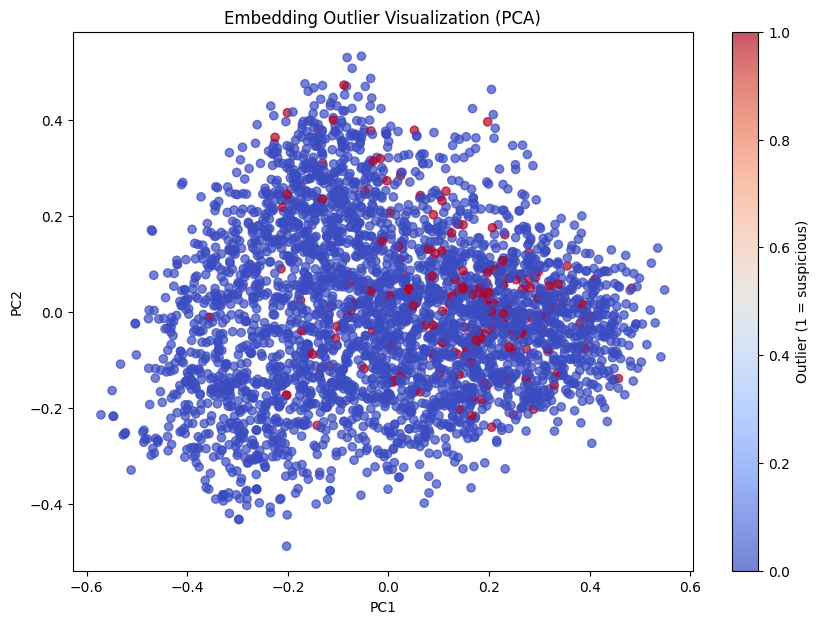

In [35]:
# Now we want to try to visualize the E-Mail embeddings in 2D space, to see if we can find any clusters or patterns:
# Let's decomposite first the embeddings (384 dimensional space) to 2D space using PCA:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=df["embedding_outlier"],
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Embedding Outlier Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Outlier (1 = suspicious)")
plt.show()


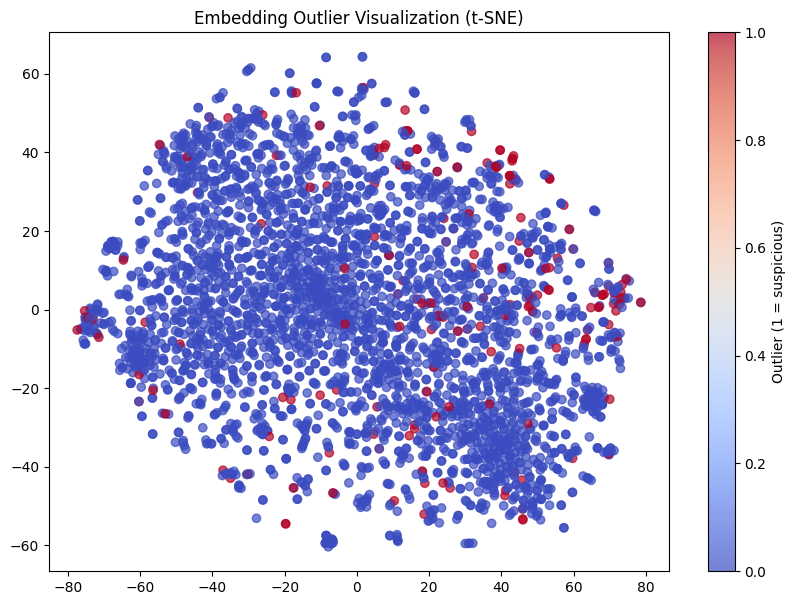

In [37]:
# Okay, the PCA deconmposition does not show a clear separation between the normal and suspicious E-Mails. Let's try t-SNE, which is better at preserving local structures in the data:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
coords_tsne = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(
    coords_tsne[:, 0],
    coords_tsne[:, 1],
    c=df["embedding_outlier"],
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Embedding Outlier Visualization (t-SNE)")
plt.colorbar(label="Outlier (1 = suspicious)")
plt.show()


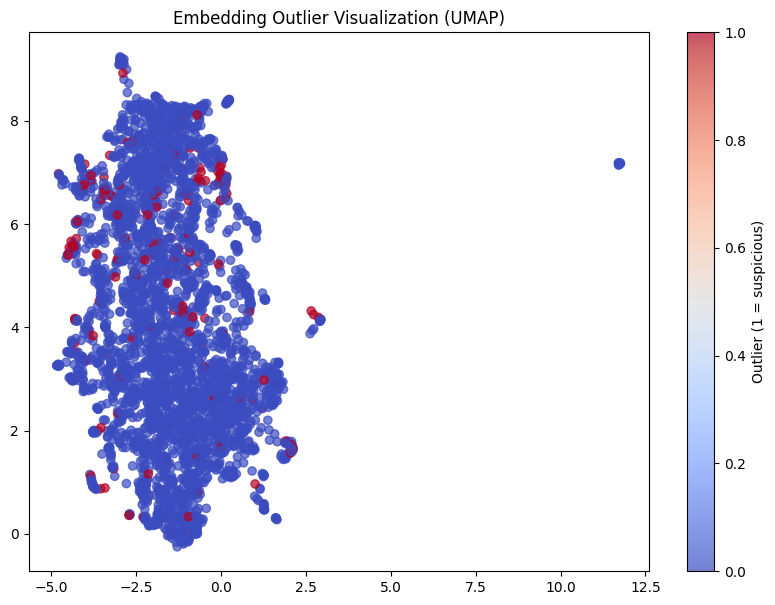

In [42]:
# Let's also try UMAP, which is another dimensionality reduction technique that is good at preserving both local and global structures in the data:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine")
coords_umap = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(
    coords_umap[:, 0],
    coords_umap[:, 1],
    c=df["embedding_outlier"],
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Embedding Outlier Visualization (UMAP)")
plt.colorbar(label="Outlier (1 = suspicious)")
plt.show()


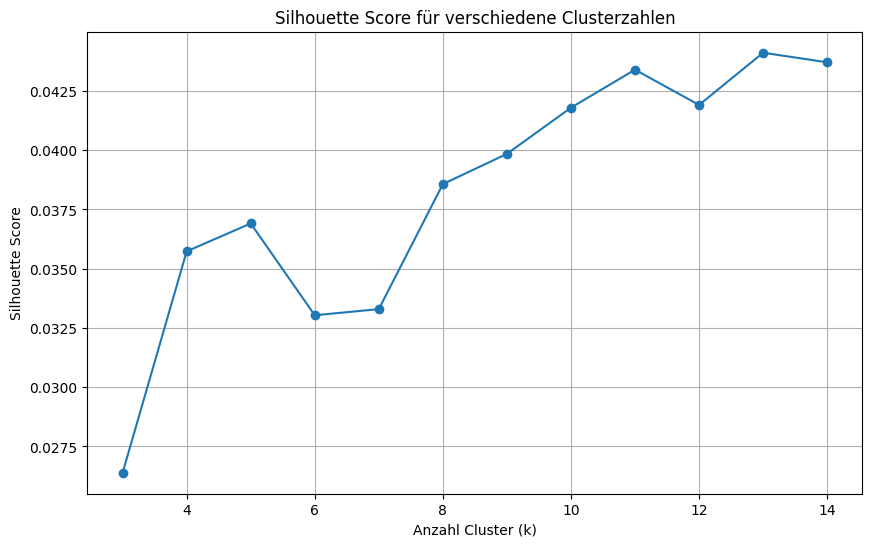

In [50]:
from sklearn.cluster import KMeans

#Let's grab the outlier emails:
outlier_df = df[df["embedding_outlier"] == 1].copy()
outlier_embeddings = embeddings[df["embedding_outlier"] == 1]


# Let's test 3-10 clusters and see which one gives us the best separation of the outliers:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
K = range(3, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(outlier_embeddings)
    score = silhouette_score(outlier_embeddings, labels)
    sil_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Score für verschiedene Clusterzahlen")
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()







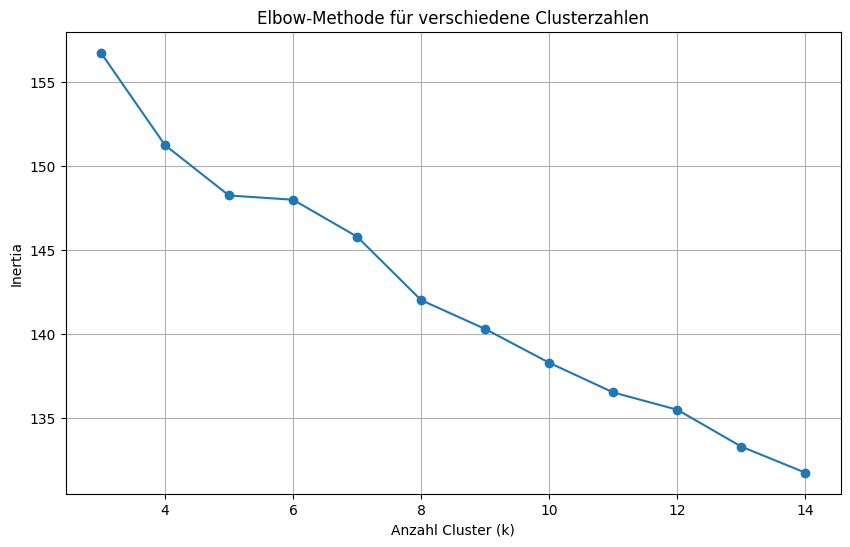

In [51]:
inertias = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(outlier_embeddings)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertias, marker='o')
plt.title("Elbow-Methode für verschiedene Clusterzahlen")
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


Choosing 5 or 11 clusters appears to make the most sense. Let's go with 5 first:

In [52]:
from sklearn.cluster import KMeans

outlier_df = df[df["embedding_outlier"] == 1].copy()
outlier_embeddings = embeddings[df["embedding_outlier"] == 1]

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
outlier_df["cluster"] = kmeans.fit_predict(outlier_embeddings)

# How many emails are in each cluster?
outlier_df["cluster"].value_counts().sort_index()


cluster
0    42
1    52
2    44
3    11
4    29
Name: count, dtype: int64

In [60]:
# Let's extract the top10 topics from each cluster by looking at the most common words in the email bodies of each cluster:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(stop_words="english", max_features=2000)
tfidf = vectorizer.fit_transform(outlier_df["body"].astype(str))
terms = vectorizer.get_feature_names_out()

for c in sorted(outlier_df["cluster"].unique()):
    idx = (outlier_df["cluster"] == c).values   # NumPy array!
    cluster_tfidf = tfidf[idx].mean(axis=0).A1
    top_idx = np.argsort(cluster_tfidf)[-10:][::-1]
    print(f"\nCluster {c} – Top-Begriffe:")
    print(", ".join(terms[i] for i in top_idx))



Cluster 0 – Top-Begriffe:
doc, org, wordsmith, ect, looks, good, words, ve, world, lavo

Cluster 1 – Top-Begriffe:
didn, john, susan, 20, congrats, don, know, org, wordsmith, actually

Cluster 2 – Top-Begriffe:
000, var, market, know, correct, let, john, ect, 75, com

Cluster 3 – Top-Begriffe:
msn, explorer, _________________________________________________________________, photos, download, http, com, intl, free, asp

Cluster 4 – Top-Begriffe:
messenger, password, msn, 713, com, http, ipayit, unavailable, click, need


In [63]:
outlier_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP_enron_email_analysis/data/out/suspicious_emails_with_clusters.csv", index=False)  
outlier_df.loc[outlier_df["cluster"] == 4, ["person", "folder", "sender", "receiver", "subject", "body"]].head(5)

,person,folder,sender,receiver,subject,body
26,arnold,inbox,dudley.poston@williams.com,jarnold@enron.com,Phone Numbers,Mine # is 918-573-5821 \nBrenden is 713-544-4214
27,arnold,inbox,my-login-request@yahoo-inc.com,jarnold@enron.com,Yahoo! ID Search Results,The search results for your forgotten Yahoo ID...
277,arnold,sent,john.arnold@enron.com,andy.zipper@enron.com,RE:,both. i have it on dutch's machine just in c...
432,arnold,sent,john.arnold@enron.com,brian.hoskins@enron.com,Re: Implementation issue on IE5.0/5.5,"yea, i'll talk to them.\n\nwho should i call?\..."
449,arnold,sent,john.arnold@enron.com,john.arnold@enron.com,NaN,speed on eol\nmessage for monday \nhow to move...


,Unnamed: 0,file,message_id,date,sender,receiver,subject,body,person,folder,embedding_outlier,embedding_score,cluster
12,12,138.txt,<27954483.1075861675545.JavaMail.evans@thyme>,"Tue, 30 Oct 2001 09:59:29 -0800 (PST)",steve.lafontaine@bankofamerica.com,jarnold@enron.com,stuff,i hpe thingsa re ok for you.obviously a shit l...,arnold,inbox,1,0.010235,1
26,26,61.txt,<7566602.1075852730998.JavaMail.evans@thyme>,"Mon, 29 Oct 2001 12:28:54 -0800 (PST)",dudley.poston@williams.com,jarnold@enron.com,Phone Numbers,Mine # is 918-573-5821 \nBrenden is 713-544-4214,arnold,inbox,1,0.002378,4
27,27,75.txt,<905155.1075855217234.JavaMail.evans@thyme>,"Sat, 15 Dec 2001 15:18:16 -0800 (PST)",my-login-request@yahoo-inc.com,jarnold@enron.com,Yahoo! ID Search Results,The search results for your forgotten Yahoo ID...,arnold,inbox,1,0.003437,4
42,42,170.txt,<5558138.1075861676444.JavaMail.evans@thyme>,"Tue, 27 Nov 2001 14:21:17 -0800 (PST)",update@briefing.com,jarnold@ect.enron.com,Give a gift that will get used!,[IMAGE] \t\n[IMAGE]\tNot this year. Give a gif...,arnold,inbox,1,0.001899,2
95,95,51.txt,<28457755.1075852729263.JavaMail.evans@thyme>,"Sun, 28 Oct 2001 18:01:42 -0800 (PST)",caroline.abramo@enron.com,john.arnold@enron.com,S+P Commodity Index,hi- not sure if you saw this with all the crap...,arnold,inbox,1,0.000226,2
